

Olá estudante!

Me chamo Rafael Meirelles e irei revisar o seu projeto hoje e em eventuais futuras submissões até que ele cumpra todos os requisitos para o aceite.
Conte comigo nessa jornada e não se preocupe se precisar ajustar alguns detalhes, é parte do processo e fundamental para que você exercite os conceitos que vem aprendendo e assim melhore a qualidade dos seus códigos e análises.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender os meus feedbacks no seu notebook. Funciona assim:


<div class="alert alert-danger">
<strong>Vermelho</strong>

Erro que precisa ser consertado, caso contrário, seu projeto não pode ser aceito

</div>

<div class="alert alert-warning">
<strong>Amarelo</strong>

Alerta de um erro não crítco, mas que pode ser corrigido para melhoria geral no seu código/análise

</div>

<div class="alert alert-success">
<strong>Verde</strong>

Elogios
</div>

<div class="alert alert-info">
<strong>Comentário do estudante</strong>

Use uma caixa azul como essa para eventuais comentários que você gostaria de fazer para mim.
</div>






# Projeto Sprint 8 - Empresa Y.Afisha

## Análise de negócios para otimização de despesas de Marketing
O objetivo desse projeto é compreender a utilização do produto da empresa pelos clientes, entender quando eles começam a comprar, quanto de receita cada cliente gera e quando das despesas serão cobertas e, com essas informações, entregar sugestões de otimização das despesas.

## Etapa 1 - Leitura do arquivo e tratamento dos dados

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
visits = pd.read_csv(
    '/datasets/visits_log_us.csv',
    dtype={'Device': 'category'},
    parse_dates=['Start Ts', 'End Ts']
)

In [4]:
print(visits.info())
print('------------------------')
print(visits['Device'].value_counts())
print('------------------------')
print(visits.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Device     359400 non-null  category      
 1   End Ts     359400 non-null  datetime64[ns]
 2   Source Id  359400 non-null  int64         
 3   Start Ts   359400 non-null  datetime64[ns]
 4   Uid        359400 non-null  uint64        
dtypes: category(1), datetime64[ns](2), int64(1), uint64(1)
memory usage: 11.3 MB
None
------------------------
desktop    262567
touch       96833
Name: Device, dtype: int64
------------------------
    Device              End Ts  Source Id            Start Ts  \
0    touch 2017-12-20 17:38:00          4 2017-12-20 17:20:00   
1  desktop 2018-02-19 17:21:00          2 2018-02-19 16:53:00   
2    touch 2017-07-01 01:54:00          5 2017-07-01 01:54:00   
3  desktop 2018-05-20 11:23:00          9 2018-05-20 10:59:00   
4  desktop 2017-12-27 14:06:0

In [5]:
orders = pd.read_csv(
    '/datasets/orders_log_us.csv',
    parse_dates=['Buy Ts']
)

In [6]:
print(orders.info())
print('------------------------')
print(orders.describe())
print('------------------------')
print(orders.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Buy Ts   50415 non-null  datetime64[ns]
 1   Revenue  50415 non-null  float64       
 2   Uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB
None
------------------------
            Revenue           Uid
count  50415.000000  5.041500e+04
mean       4.999647  9.098161e+18
std       21.818359  5.285742e+18
min        0.000000  3.135781e+14
25%        1.220000  4.533567e+18
50%        2.500000  9.102274e+18
75%        4.890000  1.368290e+19
max     2633.280000  1.844617e+19
------------------------
               Buy Ts  Revenue                   Uid
0 2017-06-01 00:10:00    17.00  10329302124590727494
1 2017-06-01 00:25:00     0.55  11627257723692907447
2 2017-06-01 00:27:00     0.37  17903680561304213844
3 2017-06-01 00:29:00   

In [7]:
costs = pd.read_csv(
    '/datasets/costs_us.csv',
    parse_dates=['dt']
)

In [8]:
print(costs.info())
print('------------------------')
print(costs.describe())
print('------------------------')
print(costs.value_counts())
print('------------------------')
print(costs.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 59.7 KB
None
------------------------
         source_id        costs
count  2542.000000  2542.000000
mean      4.857199   129.477427
std       3.181581   156.296628
min       1.000000     0.540000
25%       2.000000    21.945000
50%       4.000000    77.295000
75%       9.000000   170.065000
max      10.000000  1788.280000
------------------------
source_id  dt          costs 
1          2017-06-01  75.20     1
5          2018-02-01  298.58    1
           2018-01-25  189.62    1
           2018-01-26  151.74    1
           2018-01-27  152.74    1
                                ..
3     

In [9]:
def to_snake_case(name):
    name = name.replace(' ', '')
    name = name.replace('Ts', '_ts') # Trata o 'Ts' de 'Start Ts' e 'End Ts'
    name = name.replace('Id', '_id') # Trata o 'Id' de 'Source Id'
    name = name.lower()
    return name

visits.columns = [to_snake_case(col) for col in visits.columns]
orders.columns = [to_snake_case(col) for col in orders.columns]

print(visits.info())
print(orders.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  category      
 1   end_ts     359400 non-null  datetime64[ns]
 2   source_id  359400 non-null  int64         
 3   start_ts   359400 non-null  datetime64[ns]
 4   uid        359400 non-null  uint64        
dtypes: category(1), datetime64[ns](2), int64(1), uint64(1)
memory usage: 11.3 MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  datetime64[ns]
 1   revenue  50415 non-null  float64       
 2   uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB
None


1. Foi realizada a importação das bibliotecas a serem usadas neste projeto.
2. Foram gerados 3 DataFrames, um para cada arquivo, chamados *visits*, *orders* e *costs*, os quais contêm os dados brutos a serem trabalhados.
3. Foi utilizado os parâmetros *dtype* e *parse_dates* para que os dfs já viessem com as formatações adequadas.
4. Foram utilizados os métodos .info(), value_counts(), .describe() e .head() para realizar a análise inicial dos dados.
5. Foi criada uma função para padronizar o nome das colunas com *snake_case*.

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Excelente trabalho checando a consistência dos dados.

Sempre importante para garantir uma análise robusta!
</div>




## Etapa 2 - Preparação dos dados
Essa etapa visa otimizar a próxima etapa de análise, colocando-a em evidência, deixando a menor quantidade de código. 

In [10]:
visits['date'] = visits['start_ts'].dt.date
visits['date'] = pd.to_datetime(visits['date'])
visits['week'] = visits['start_ts'].dt.isocalendar().week.astype(int)
visits['month'] = visits['start_ts'].dt.to_period('M')
costs['month'] = costs['dt'].dt.to_period('M')

print(visits.info())
print(costs.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  category      
 1   end_ts     359400 non-null  datetime64[ns]
 2   source_id  359400 non-null  int64         
 3   start_ts   359400 non-null  datetime64[ns]
 4   uid        359400 non-null  uint64        
 5   date       359400 non-null  datetime64[ns]
 6   week       359400 non-null  int64         
 7   month      359400 non-null  period[M]     
dtypes: category(1), datetime64[ns](3), int64(2), period[M](1), uint64(1)
memory usage: 19.5 MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs     

Foram incluídas as colunas **date**, **week** e **month** no df *visits* e apenas **month** no df *costs* para as futuras análises.

In [11]:
orders = orders[orders['buy_ts'] < '2018-06-01']
costs = costs[costs['dt'] < '2018-06-01']

print(orders.tail(10).sort_values('buy_ts'))
print('------------------------')
print(costs.tail(10).sort_values('dt'))

                   buy_ts  revenue                   uid
50404 2018-05-31 23:36:00     0.61  14926823272464019002
50405 2018-05-31 23:36:00     0.61   1551265230644458155
50406 2018-05-31 23:40:00     1.16  13121453305610619664
50407 2018-05-31 23:40:00     2.26  15576344609395725707
50408 2018-05-31 23:42:00     0.92  15854392578508828030
50409 2018-05-31 23:43:00     3.67   1805512004303848280
50410 2018-05-31 23:50:00     4.64  12296626599487328624
50411 2018-05-31 23:50:00     5.80  11369640365507475976
50412 2018-05-31 23:54:00     0.30   1786462140797698849
50413 2018-05-31 23:56:00     3.67   3993697860786194247
------------------------
      source_id         dt  costs    month
2532         10 2018-05-22  21.70  2018-05
2533         10 2018-05-23   7.42  2018-05
2534         10 2018-05-24  10.79  2018-05
2535         10 2018-05-25  22.21  2018-05
2536         10 2018-05-26   7.89  2018-05
2537         10 2018-05-27   9.92  2018-05
2538         10 2018-05-28  21.26  2018-05
2539

Foi removido o dia 01/06/2018 pois era o único dado desse mês o que pode influenciar toda a análise posteriormente.

In [14]:
user_source = visits.sort_values('start_ts').groupby('uid').first()['source_id'].reset_index()
user_source.columns = ['uid', 'acquisition_source']
first_visit = visits.groupby('uid')['start_ts'].min().reset_index()
first_visit.columns = ['uid', 'first_visit_ts']
first_order = orders.groupby('uid')['buy_ts'].min().reset_index()
first_order.columns = ['uid', 'first_order_ts']
first_order['first_order_month'] = first_order['first_order_ts'].dt.to_period('M')
buyers_source = pd.merge(first_order, user_source, on='uid')
orders_merged = pd.merge(orders, first_order[['uid', 'first_order_month']], on='uid')
orders_merged['order_month'] = orders_merged['buy_ts'].dt.to_period('M')
orders_merged['cohort_lifetime'] = (
    (orders_merged['order_month'].view('int64') 
     - orders_merged['first_order_month'].view('int64'))
)
orders_with_source = pd.merge(orders_merged, user_source, on='uid')

print(user_source.head(10))
print(f"\n{first_visit.head(10)}")
print(f"\n{first_order.head(10)}")
print(f"\n{buyers_source.head(10)}")
print(f"\n{orders_merged.head(10)}")
print(f"\n{orders_with_source.head(10)}")

               uid  acquisition_source
0   11863502262781                   3
1   49537067089222                   2
2  297729379853735                   3
3  313578113262317                   2
4  325320750514679                   5
5  397399764396656                   4
6  407573351275847                   2
7  498809019029702                   4
8  526778907996220                   2
9  577434573913691                   9

               uid      first_visit_ts
0   11863502262781 2018-03-01 17:27:00
1   49537067089222 2018-02-06 15:55:00
2  297729379853735 2017-06-07 18:47:00
3  313578113262317 2017-09-18 22:49:00
4  325320750514679 2017-09-30 14:29:00
5  397399764396656 2018-01-18 12:32:00
6  407573351275847 2017-06-17 13:40:00
7  498809019029702 2018-02-21 22:09:00
8  526778907996220 2017-10-21 17:51:00
9  577434573913691 2018-01-28 14:15:00

                uid      first_order_ts first_order_month
0   313578113262317 2018-01-03 21:51:00           2018-01
1  1575281904278712 2017

Foi identificado os usuários (*user_source*) e os compradores (*buyer_source*) a partir da sua origem (anúncio) e também os acessos e as compras a partir dos anúncios que levaram o cliente ao produto.

In [15]:
cohorts = orders_merged.groupby(
    ['first_order_month', 'cohort_lifetime']).agg(
    {'revenue': 'sum'}
).reset_index()
cohort_revenue_source = orders_with_source.groupby(
    ['first_order_month', 'acquisition_source', 'order_month']).agg(
    {'revenue': 'sum'}
).reset_index()
cohort_revenue_source['cohort_lifetime'] = (
    (cohort_revenue_source['order_month'].view('int64') 
     - cohort_revenue_source['first_order_month'].view('int64'))
)
print(cohorts.head(10))
print(f"\n{cohort_revenue_source.head(10)}")

  first_order_month  cohort_lifetime  revenue
0           2017-06                0  9557.49
1           2017-06                1   981.82
2           2017-06                2   885.34
3           2017-06                3  1931.30
4           2017-06                4  2068.58
5           2017-06                5  1487.92
6           2017-06                6  1922.74
7           2017-06                7  1176.56
8           2017-06                8  1119.15
9           2017-06                9  1225.51

  first_order_month  acquisition_source order_month  revenue  cohort_lifetime
0           2017-06                   1     2017-06  1378.70                0
1           2017-06                   1     2017-07   414.98                1
2           2017-06                   1     2017-08   419.43                2
3           2017-06                   1     2017-09   714.24                3
4           2017-06                   1     2017-10   811.20                4
5           2017-06      

Foi feito um coorte com a receita e o anúncio de origem.

In [16]:
orders_by_cohort = orders_merged.groupby(
    ['first_order_month', 'cohort_lifetime']).agg(
    {'uid': ['count', 'nunique']}
).reset_index()
orders_by_cohort.columns = ['first_order_month', 'cohort_lifetime', 'n_orders', 'n_buyers']
orders_by_cohort['purchase_frequency'] = orders_by_cohort['n_orders'] / orders_by_cohort['n_buyers']

print(orders_by_cohort.head(10))

  first_order_month  cohort_lifetime  n_orders  n_buyers  purchase_frequency
0           2017-06                0      2354      2023            1.163618
1           2017-06                1       177        61            2.901639
2           2017-06                2       174        50            3.480000
3           2017-06                3       226        54            4.185185
4           2017-06                4       292        88            3.318182
5           2017-06                5       218        67            3.253731
6           2017-06                6       276        62            4.451613
7           2017-06                7       174        47            3.702128
8           2017-06                8       212        58            3.655172
9           2017-06                9       153        45            3.400000


Foi feito um coorte das compras, incluindo a frequência delas.

In [17]:
buyers_by_month_source = buyers_source.groupby(
    ['first_order_month', 'acquisition_source']).agg(
    {'uid': 'nunique'}
).reset_index()
buyers_by_month_source.columns = ['month', 'source_id', 'n_buyers']
costs_monthly_source = costs.groupby(
    ['month', 'source_id']
)['costs'].sum().reset_index()

print(buyers_by_month_source.tail(10))
print(f"\n{costs_monthly_source.head(10)}")

      month  source_id  n_buyers
75  2018-04          5       430
76  2018-04          9        43
77  2018-04         10       107
78  2018-05          1       241
79  2018-05          2       412
80  2018-05          3       844
81  2018-05          4       804
82  2018-05          5       497
83  2018-05          9        60
84  2018-05         10       130

     month  source_id    costs
0  2017-06          1  1125.61
1  2017-06          2  2427.38
2  2017-06          3  7731.65
3  2017-06          4  3514.80
4  2017-06          5  2616.12
5  2017-06          9   285.22
6  2017-06         10   314.22
7  2017-07          1  1072.88
8  2017-07          2  2333.11
9  2017-07          3  7674.37


Foi identificado os clientes mensais a partir dos anúncios e os custos mensais desses anúncios.

## Etapa 3 - Análise dos dados

### 1. Produto

#### Quantas pessoas usam o produto cada dia, semana e mês? (DAU, WAU e MAU)

In [18]:
dau = visits.groupby('date')['uid'].nunique().mean()
wau = visits.groupby('week')['uid'].nunique().mean()
mau = visits.groupby('month')['uid'].nunique().mean()

print("---Métricas de Uso---\n")
usage_metrics = pd.DataFrame({
    'Métrica': ['DAU', 'WAU', 'MAU'],
    'Valor Médio': [dau, wau, mau]
})
print(usage_metrics.to_string(index=False, float_format="%.2f"))

---Métricas de Uso---

Métrica  Valor Médio
    DAU       907.99
    WAU      5825.29
    MAU     23228.42


#### Quantas sessões ocorrem por dia? (um usuário pode realizar várias sessões)

In [19]:
daily_sessions = visits.groupby('date').size()
avg_daily_sessions = daily_sessions.mean()
    
print("---Volume de Sessões Diárias---\n")
print(f"Média Diária de Sessões: {avg_daily_sessions:.2f}")

---Volume de Sessões Diárias---

Média Diária de Sessões: 987.36


In [20]:
sessions_per_user = avg_daily_sessions / dau

print("---Quantidade de acessos diários---\n")
print(f"Média de acesso diário por usuário: {sessions_per_user:.2f}")

---Quantidade de acessos diários---

Média de acesso diário por usuário: 1.09


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Volumetrias de usuários e de sessões entregues.
</div>




#### Qual comprimento tem cada sessão?

In [21]:
visits['session_duration'] = visits['end_ts'] - visits['start_ts']
visits_clean = visits.query('session_duration > "0 seconds"').copy()
visits_clean = visits_clean[visits_clean['start_ts'] < '2018-06-01']
visits_clean['session_duration_sec'] = visits_clean['session_duration'].dt.total_seconds()
duration_stats = visits_clean['session_duration_sec'].describe(percentiles=[.5, .75, .95])
mean_duration = pd.to_timedelta(duration_stats['mean'], unit='s')
median_duration = pd.to_timedelta(duration_stats['50%'], unit='s')

print("---Duração das Sessões---")
print(f"\nDuração Média da Sessão:\n {mean_duration}")
print(f"\nDuração Mediana da Sessão:\n {median_duration}")
print("\nEstatísticas Detalhadas (em segundos):")
print(duration_stats.to_string(float_format="%.2f"))

---Duração das Sessões---

Duração Média da Sessão:
 0 days 00:11:54.169515828

Duração Mediana da Sessão:
 0 days 00:06:00

Estatísticas Detalhadas (em segundos):
count   323604.00
mean       714.17
std       1026.35
min         19.00
50%        360.00
75%        900.00
95%       2400.00
max      42660.00


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Excelente trabalho checando a consistência dos dados.

Sempre importante para garantir uma análise robusta!
</div>


VAroável da duração das sessões foi investigada adequadamente.

#### Com que frequência os usuários voltam?

In [22]:
sticky_factor_dm = dau / mau
sticky_factor_dw = dau / wau
print("---Frequência de Retorno---\n")
print(f"Taxa de retenção dia/mês: {sticky_factor_dm:.2%}")
print(f"Taxa de retenção dia/semana: {sticky_factor_dw:.2%}")

---Frequência de Retorno---

Taxa de retenção dia/mês: 3.91%
Taxa de retenção dia/semana: 15.59%


##### Observações:

- O volume de tráfego é quase idêntico ao número de usuários diários (≈ 1.09 sessões/usuário). Isso sugere que, em média, a maioria dos usuários realiza apenas uma sessão e confirma que o produto é utilizado para tarefas pontuais, sem múltiplas visitas ao longo do dia.
- A duração média de ≈ 12 min diários e a mediana de 6 min, mostram que, uma vez dentro do produto, o usuário dedica tempo de qualidade, o que é suficiente para a exploração e conversão em vendas. A mediana sugere também uma experiência de uso objetiva, enquanto a média indica a existência de um nicho de usuários mais engajados.
- A taxa de retorno é o ponto crítico, com apenas 3,9% de retenção mensal e 15,6% semanal.

Resumindo, o produto tem alto engajamento por sessão, mas baixa aderência (retenção) dos clientes.


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Retenção foi endereçada adequadamente.

</div>




### 2. Vendas

#### Quando as pessoas começam a comprar?

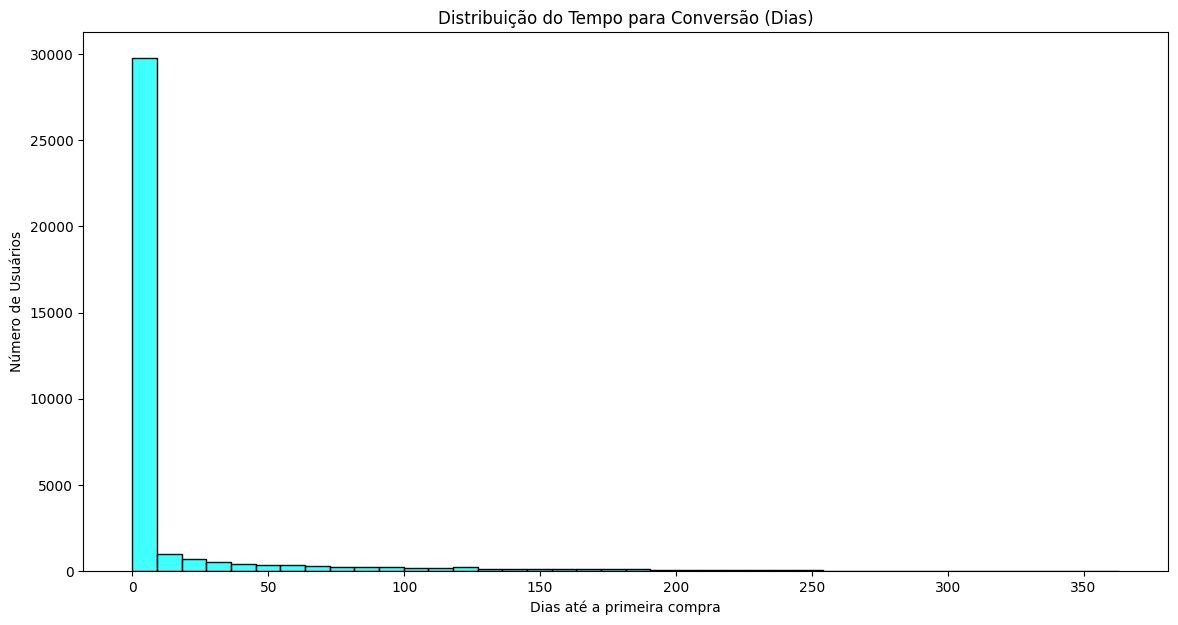

Mediana de dias para conversão: 0


In [23]:
conversion_time = pd.merge(first_visit, first_order, on='uid')
conversion_time['days_to_convert'] = (
    (conversion_time['first_order_ts'] - conversion_time['first_visit_ts']).dt.days
)

plt.figure(figsize=(14, 7))
sns.histplot(conversion_time['days_to_convert'], bins=40, color='aqua')
plt.title('Distribuição do Tempo para Conversão (Dias)')
plt.xlabel('Dias até a primeira compra')
plt.ylabel('Número de Usuários')
plt.show()

print(f"Mediana de dias para conversão: {conversion_time['days_to_convert'].median():.0f}")

#### Quantos pedidos os clientes fazem durante um determinado período de tempo?

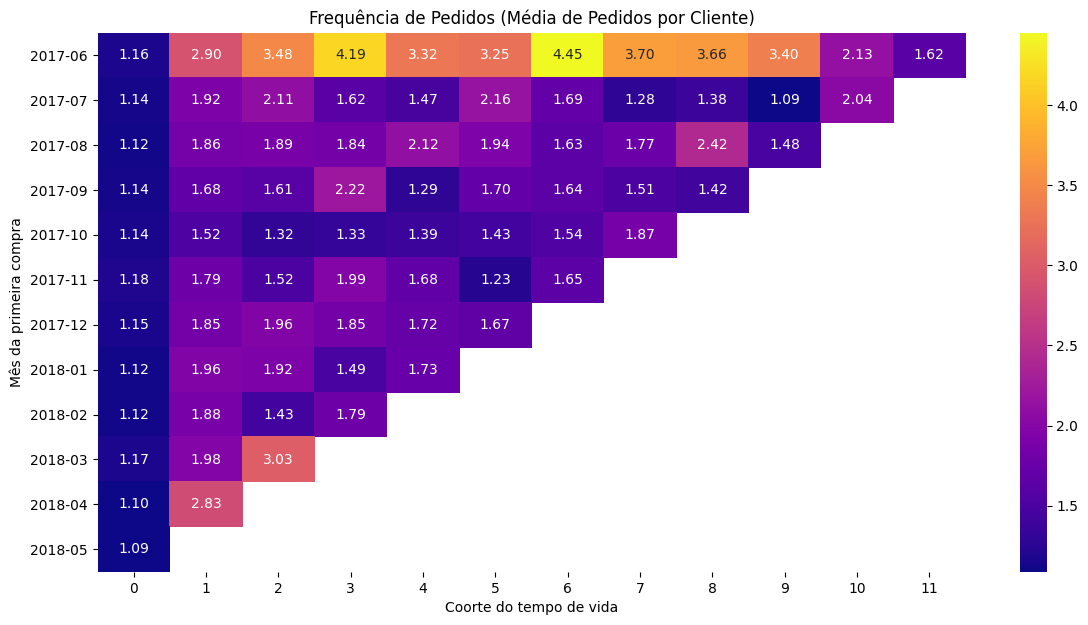

Média de pedidos por cliente no mês de aquisição (Mês 0): 1.14


In [24]:
frequency_pivot = orders_by_cohort.pivot_table(
    index='first_order_month',
    columns='cohort_lifetime',
    values='purchase_frequency',
    aggfunc='mean'
)
plt.figure(figsize=(14, 7))
sns.heatmap(frequency_pivot, annot=True, fmt='.2f', cmap='plasma')
plt.title('Frequência de Pedidos (Média de Pedidos por Cliente)')
plt.xlabel('Coorte do tempo de vida')
plt.ylabel('Mês da primeira compra')
plt.show()

avg_freq_month_0 = orders_by_cohort[orders_by_cohort['cohort_lifetime'] == 0]['purchase_frequency'].mean()
print(f"Média de pedidos por cliente no mês de aquisição (Mês 0): {avg_freq_month_0:.2f}")

In [25]:
user_orders = orders.groupby('uid').agg({
    'buy_ts': 'count',
    'revenue': 'sum'
}).rename(columns={'buy_ts': 'n_orders', 'revenue': 'total_revenue'})

order_counts = user_orders['n_orders'].value_counts().sort_index()
order_counts_pct = (user_orders['n_orders'].value_counts(normalize=True) * 100).sort_index()

print("--- Distribuição de Pedidos por Cliente ---")
dist_df = pd.DataFrame({
    'Qtd Pedidos': order_counts.index,
    'Total Clientes': order_counts.values,
    '% do Total': order_counts_pct.values
})
print(dist_df.to_string(index=False, float_format="%.2f"))

--- Distribuição de Pedidos por Cliente ---
 Qtd Pedidos  Total Clientes  % do Total
           1           30230       82.77
           2            4395       12.03
           3            1086        2.97
           4             375        1.03
           5             147        0.40
           6              79        0.22
           7              41        0.11
           8              24        0.07
           9               7        0.02
          10              15        0.04
          11               8        0.02
          12              10        0.03
          13               8        0.02
          14               4        0.01
          15               5        0.01
          16               7        0.02
          17               6        0.02
          18               3        0.01
          19               4        0.01
          20               1        0.00
          21               3        0.01
          22               2        0.01
          23 

#### Qual é o volume médio de uma compra?

In [26]:
monthly_revenue = orders_merged.groupby('order_month').agg({'revenue': 'sum', 'uid': 'count'}).reset_index()
monthly_revenue.columns = ['month', 'total_revenue', 'n_orders']
monthly_revenue['avg_ticket'] = monthly_revenue['total_revenue'] / monthly_revenue['n_orders']

print("---Ticket Médio Mensal---\n")
print(monthly_revenue[['month', 'avg_ticket']].to_string(index=False, float_format="%.2f"))

---Ticket Médio Mensal---

  month  avg_ticket
2017-06        4.06
2017-07        5.31
2017-08        4.85
2017-09        5.42
2017-10        4.93
2017-11        4.78
2017-12        5.85
2018-01        4.11
2018-02        4.84
2018-03        5.41
2018-04        5.15
2018-05        4.77


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Tempo até a primeira compra e volume por compa e safra foram investigados.
</div>




#### Quanto dinheiro (receita) eles trazem para a empresa (LTV)?

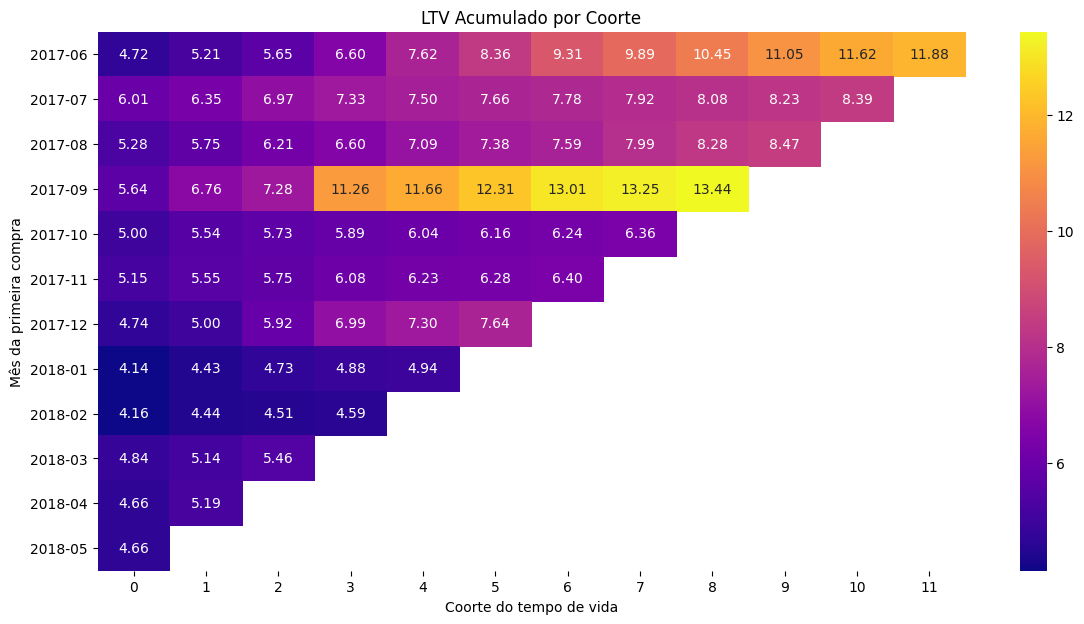

Média do LTV total: R$ 6.90


In [27]:
cohort_sizes = first_order.groupby(
    'first_order_month').agg(
    {'uid': 'nunique'}).reset_index()
cohort_sizes.columns = ['first_order_month', 'n_buyers']

report = pd.merge(cohort_sizes, cohorts, on='first_order_month')
report['ltv'] = report['revenue'] / report['n_buyers']

ltv_pivot = report.pivot_table(
    index='first_order_month', 
    columns='cohort_lifetime', 
    values='ltv', 
    aggfunc='sum'
).cumsum(axis=1)

plt.figure(figsize=(14, 7))
sns.heatmap(ltv_pivot, annot=True, fmt='.2f', cmap='plasma')
plt.title('LTV Acumulado por Coorte')
plt.xlabel('Coorte do tempo de vida')
plt.ylabel('Mês da primeira compra')
plt.show()

ltv_mean = report['revenue'].sum() / report['n_buyers'].unique().sum()

print(f"Média do LTV total: R$ {ltv_mean:.2f}")

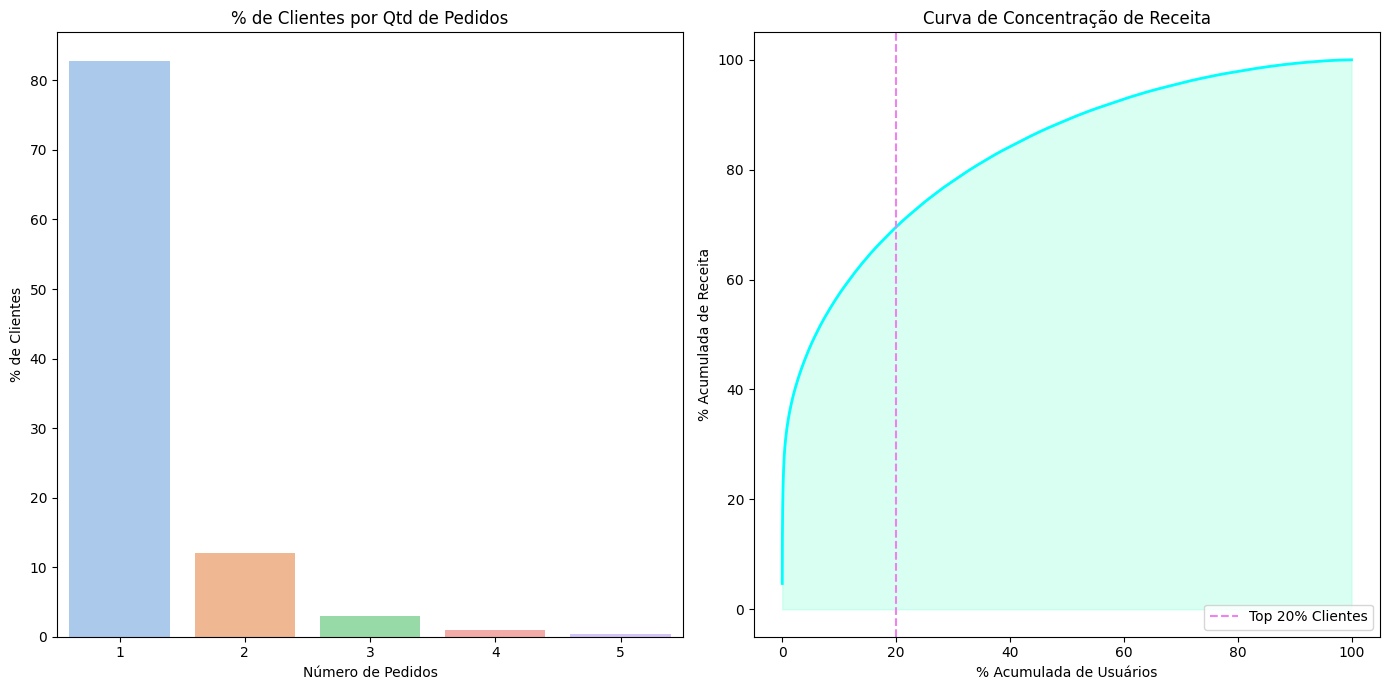

LTV Médio (Sem o Top 1% de Outliers): R$ 4.59
Impacto dos Outliers: 50.49% de distorção


In [28]:
user_orders_sorted = user_orders.sort_values('total_revenue', ascending=False)
user_orders_sorted['cum_revenue_pct'] = user_orders_sorted['total_revenue'].cumsum() / user_orders_sorted['total_revenue'].sum() * 100
user_orders_sorted['cum_users_pct'] = range(1, len(user_orders_sorted) + 1)
user_orders_sorted['cum_users_pct'] = user_orders_sorted['cum_users_pct'] / len(user_orders_sorted) * 100

plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
sns.barplot(x=dist_df['Qtd Pedidos'].head(5), y=dist_df['% do Total'].head(5), palette='pastel')
plt.title('% de Clientes por Qtd de Pedidos')
plt.xlabel('Número de Pedidos')
plt.ylabel('% de Clientes')

plt.subplot(1, 2, 2)
plt.plot(user_orders_sorted['cum_users_pct'], user_orders_sorted['cum_revenue_pct'], color='aqua', linewidth=2)
plt.fill_between(user_orders_sorted['cum_users_pct'], user_orders_sorted['cum_revenue_pct'], color='aquamarine', alpha=0.3)
plt.axvline(x=20, color='violet', linestyle='--', label='Top 20% Clientes')
plt.title('Curva de Concentração de Receita')
plt.xlabel('% Acumulada de Usuários')
plt.ylabel('% Acumulada de Receita')
plt.legend()

plt.tight_layout()
plt.show()

threshold = user_orders['total_revenue'].quantile(0.99)
ltv_no_outliers = user_orders[user_orders['total_revenue'] < threshold]['total_revenue'].mean()

print(f"LTV Médio (Sem o Top 1% de Outliers): R$ {ltv_no_outliers:.2f}")
print(f"Impacto dos Outliers: {((user_orders['total_revenue'].mean()/ltv_no_outliers)-1)*100:.2f}% de distorção")

#####  Observações:

- A mediana de conversão é 0, ou seja, os clientes compram no mesmo dia em que acessam. Já a média de pedidos por cliente no primeiro mês é de 1,14, mostrando que eles realizam pelo menos 1 pedido por mês. Contudo, com a tabela de distribuição de pedidos por clientes, nota-se que a maior concentração é de pedidos únicos, com uma presença de 82,77%, ressaltando a falta de retenção de clientes.  
- O ticket médio mensal apresenta baixa volatilidade, variando apenas 1,79 entre o mínimo (4,06) e o máximo (5,85), o que demonstra estabilidade no valor gasto por transação. A coorte de junho/2017 foi a que apresentou o menor ticket médio inicial, mas converteu-se na coorte com maior recorrência. Isso sugere que uma estratégia de baixa barreira de entrada é eficaz para fidelizar o cliente a longo prazo, mas devem-se obter dados mais específicos dessas compras iniciais para entender o que levou ao comportamento recorrente desses clientes.
- Nota-se que o LTV médio está em 6,90, mas ao excluir o Top 1% de *outliers*, reduz essa métrica para R$ 4,59. Isso revela uma distorção de 50,49%, indicando que nossa rentabilidade depende excessivamente de poucos supercompradores, enquanto a base massiva (82,77%) compra apenas uma vez.

Resumindo, a receita basicamente é obtida de novos clientes e não de recompras, mas 50% dela se obtém dos supercompradores fiéis.

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

LTV foi investigado adequadamente, incluindo a presença de um gráfico de cohort para melhor compreensão do efeito da retenção.
</div>




### 3. Marketing

#### Quanto dinheiro foi gasto?

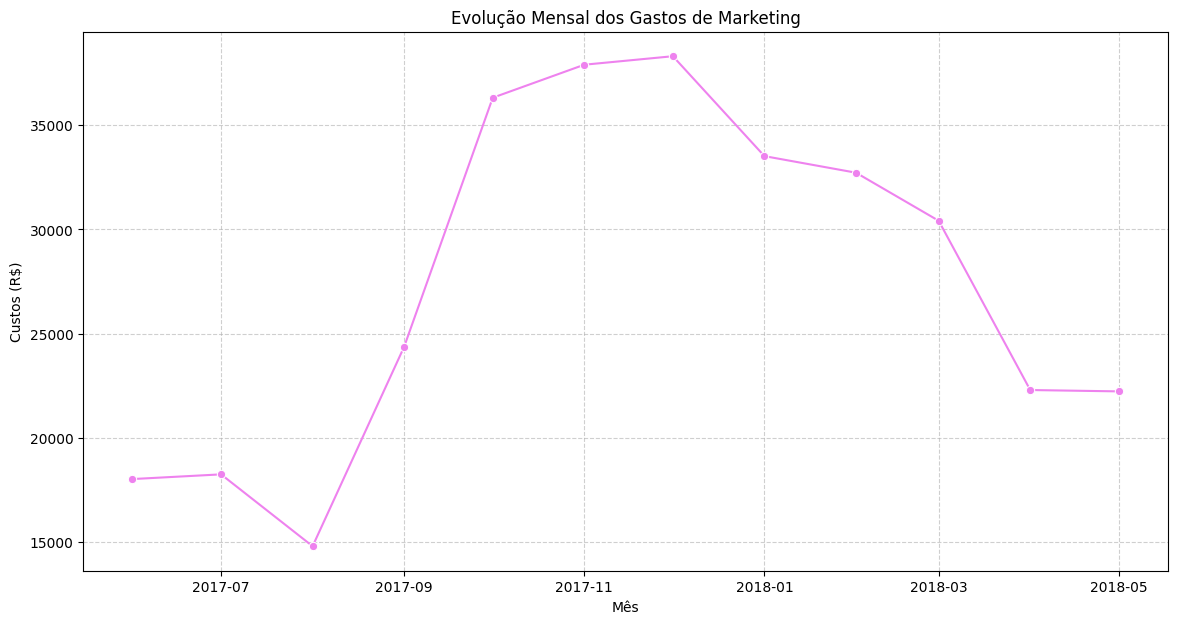


Gasto Total em Marketing: R$ 329,131.62

---Gastos por Origem---

 source_id     costs
         3 141321.63
         4  61073.60
         5  51757.10
         2  42806.04
         1  20833.27
        10   5822.49
         9   5517.49


In [29]:
total_spent = costs['costs'].sum()
costs_by_source = costs.groupby('source_id')['costs'].sum().reset_index().sort_values(by='costs', ascending=False)

monthly_costs = costs.groupby('month')['costs'].sum().reset_index()
plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_costs, x=monthly_costs['month'].dt.to_timestamp(), y='costs', color='violet', marker='o')
plt.title('Evolução Mensal dos Gastos de Marketing')
plt.ylabel('Custos (R$)')
plt.xlabel('Mês')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"\nGasto Total em Marketing: R$ {total_spent:,.2f}")
print("\n---Gastos por Origem---\n")
print(costs_by_source.to_string(index=False, float_format="%.2f"))

#### Quanto custou a aquisição de clientes para cada origem?

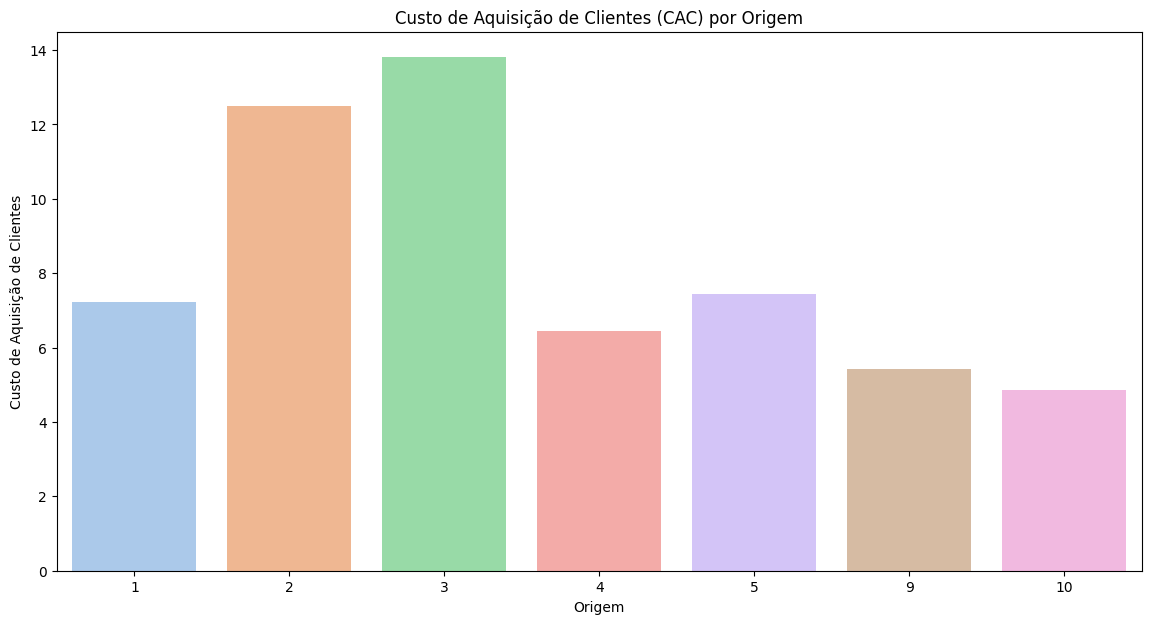


---CAC Médio por Origem---

 source_id   cac
        10  4.87
         9  5.41
         4  6.44
         1  7.21
         5  7.45
         2 12.50
         3 13.80


In [30]:
cac_report = pd.merge(buyers_by_month_source, costs_monthly_source, on=['month', 'source_id'])
cac_report['cac'] = cac_report['costs'] / cac_report['n_buyers']

avg_cac_source = cac_report.groupby('source_id')['cac'].mean().reset_index().sort_values(by='cac')

plt.figure(figsize=(14, 7))
sns.barplot(data=avg_cac_source, x='source_id', y='cac', palette='pastel')
plt.title('Custo de Aquisição de Clientes (CAC) por Origem')
plt.ylabel('Custo de Aquisição de Clientes')
plt.xlabel('Origem')
plt.show()

print("\n---CAC Médio por Origem---\n")
print(avg_cac_source.to_string(index=False, float_format="%.2f"))

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Custos por período e por mês foram investigados corretamente.
</div>




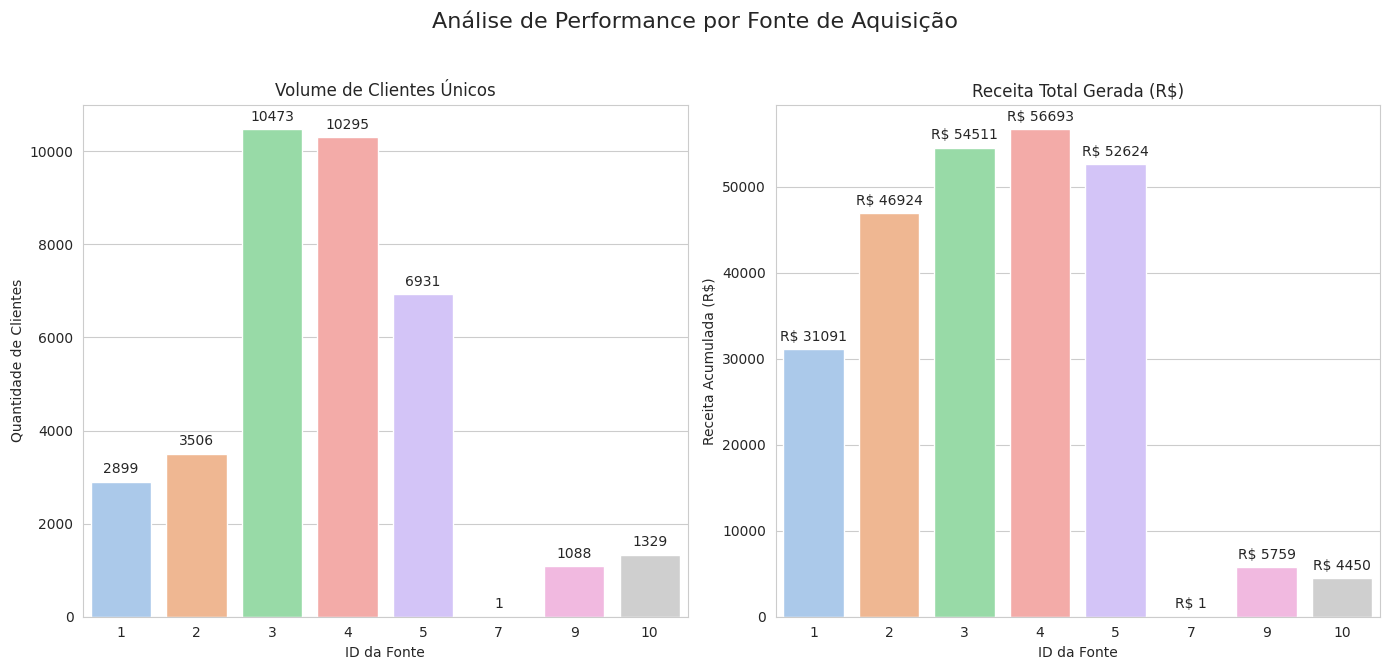

---Clientes e Receita por Origem---
 source_id  n_buyers  revenue
         4     10295 56693.41
         3     10473 54511.24
         5      6931 52624.02
         2      3506 46923.61
         1      2899 31090.55
         9      1088  5759.40
        10      1329  4450.33
         7         1     1.22


In [31]:
source_map = first_visit.merge(
    visits[['uid', 'start_ts', 'source_id']], 
    left_on=['uid', 'first_visit_ts'], 
    right_on=['uid', 'start_ts'], 
    how='left'
)
source_map = source_map[['uid', 'source_id']].drop_duplicates(subset='uid')
source_map.columns = ['uid', 'source_id']
orders_with_source = orders.merge(source_map, on='uid', how='left')
report_marketing = orders_with_source.groupby('source_id').agg(
    total_revenue=('revenue', 'sum'),
    total_buyers=('uid', 'nunique')
).reset_index()

sns.set_style("whitegrid")
palette = sns.color_palette("pastel")

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle('Análise de Performance por Fonte de Aquisição', fontsize=16)

sns.barplot(
    x='source_id', 
    y='total_buyers', 
    data=report_marketing.sort_values(by='total_buyers', ascending=False), 
    ax=axes[0], 
    palette=palette
)
axes[0].set_title('Volume de Clientes Únicos')
axes[0].set_xlabel('ID da Fonte')
axes[0].set_ylabel('Quantidade de Clientes')

for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.0f}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha='center', va='center', xytext=(0, 9), textcoords='offset points')

sns.barplot(
    x='source_id', 
    y='total_revenue', 
    data=report_marketing.sort_values(by='total_revenue', ascending=False), 
    ax=axes[1], 
    palette=palette
)
axes[1].set_title('Receita Total Gerada (R$)')
axes[1].set_xlabel('ID da Fonte')
axes[1].set_ylabel('Receita Acumulada (R$)')

for p in axes[1].patches:
    axes[1].annotate(f'R$ {p.get_height():.0f}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

report_buyers_revenue = orders_with_source.groupby('source_id').agg(
    n_buyers=('uid', 'nunique'),
    revenue=('revenue', 'sum')
).sort_values(by='revenue', ascending=False).reset_index()

print("---Clientes e Receita por Origem---")
print(report_buyers_revenue.to_string(index=False, float_format="%.2f"))

#### Os investimentos valeram a pena (ROI)?

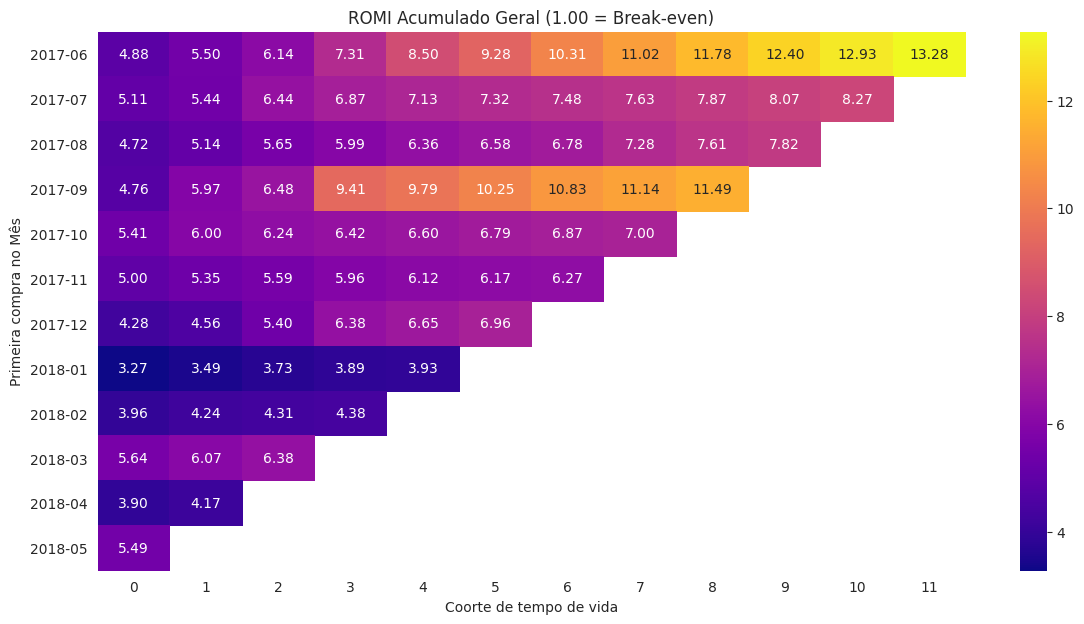


---ROMI Final Estimado por Origem---

 source_id  final_romi
         1       20.03
         5       13.13
         9       13.12
         2       12.42
         4       10.32
        10        8.29
         3        4.62


In [32]:
report_romi = pd.merge(cohort_revenue_source, buyers_by_month_source, left_on=['first_order_month', 'acquisition_source'], right_on=['month', 'source_id'])
report_romi['ltv'] = report_romi['revenue'] / report_romi['n_buyers']
report_romi = pd.merge(report_romi, cac_report[['month', 'source_id', 'cac']], on=['month', 'source_id'])
report_romi['romi'] = report_romi['ltv'] / report_romi['cac']

romi_pivot = report_romi.pivot_table(
    index='first_order_month',
    columns='cohort_lifetime',
    values='romi',
    aggfunc='sum'
).cumsum(axis=1)

plt.figure(figsize=(14, 7))
sns.heatmap(romi_pivot, annot=True, fmt='.2f', cmap='plasma')
plt.title('ROMI Acumulado Geral (1.00 = Break-even)')
plt.ylabel('Primeira compra no Mês')
plt.xlabel('Coorte de tempo de vida')
plt.show()

final_romi_source = report_romi.groupby('source_id').agg({'ltv': 'sum', 'cac': 'mean'}).reset_index()
final_romi_source['final_romi'] = final_romi_source['ltv'] / final_romi_source['cac']
print("\n---ROMI Final Estimado por Origem---\n")
print(final_romi_source[['source_id', 'final_romi']].sort_values(by='final_romi', ascending=False).to_string(index=False, float_format="%.2f"))

##### Observações:

- O top 3 de gastos em anúncios concentra-se nas fontes 3, 4 e 5, que juntas somam 77,2% do investimento total.
- A Fonte 3 apresenta o maior risco: detém 42,9% do orçamento, mas possui o CAC mais caro (13,80), ou seja, quase 3x o nosso LTV Real de 4,59, além de ter o pior ROMI (4,62x).
- Em contrapartida, a Fonte 1 é a nossa maior eficiência, com um ROMI de 20,03x, indicando que atrai clientes de altíssimo valor.
- As fontes 9 e 10 possuem os menores CACs e, embora tenham investimentos baixos, entregam retornos sólidos (13,12x e 8,29x). A Fonte 10 é a que mais se aproxima da sustentabilidade para o cliente médio, com CAC de 4,87.

Resumindo, deve-se realocar o investimento da fonte 3 para a fonte 4, que lidera em receita com ROMI saudável de 10,32x, e para a fonte 1, diante do seu alto retorno. Já as fontes 9 e 10 devem ser testadas com orçamentos maiores, pois são canais de aquisição baratos e com bom retorno.

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Análises de retorno sob diferentes quebras foram apresentadas para compreensão da eficiê
</div>




## Etapa 4 - Conclusão geral e recomendações sobre o investimento em Marketing

        O presente projeto foi estruturado em três etapas fundamentais, iniciando com a importação de bibliotecas e o carregamento dos dados brutos nos DataFrames visits, orders e costs, utilizando parâmetros de dtype e parse_dates para garantir a integridade dos tipos de dados. Após uma análise exploratória inicial com métodos como .info() e .describe(), foi implementada uma função de padronização para snake_case, seguindo para a engenharia de atributos, criando colunas temporais (data, semana, mês) e mapeando a jornada do cliente desde a origem do anúncio (source_id) até a conversão. Esta base técnica permitiu a criação de coortes precisas de receita, frequência de compra e custos, fundamentando as análises de Produto, Vendas e Marketing que sustentam nossas recomendações.

        A análise integrada revela que o negócio possui um ciclo de conversão imediato e alto engajamento por sessão (6-12 min), mas enfrenta um risco crítico de sustentabilidade devido à baixa retenção mensal (3,9%) e à extrema dependência de novos clientes, visto que 82,77% realizaram apenas uma compra. Foi identificado que o LTV médio de R$ 6,90 é um "LTV mascarado" inflado por outliers; o LTV Real é de R$ 4,59 (uma distorção de 50,49%), o que exige que o teto de Custo de Aquisição (CAC) seja urgentemente reavaliado para garantir a lucratividade da base massiva de clientes, que hoje depende de poucos supercompradores para gerar 50% da receita.

        Visando os pontos acima citados, estrategicamente, recomenda-se a realocação imediata do orçamento da Fonte 3, que detém 42,9% do investimento, mas opera com o pior ROMI (4,62x) e um CAC proibitivo de R$ 13,80 (3x o LTV Real). O capital deve ser direcionado para a Fonte 4, que lidera em receita absoluta (R$ 56.693,41) com retorno saudável (10,32x), e para a Fonte 1, que apresenta a maior eficiência do ecossistema com um ROMI de 20,03x. As fontes 9 e 10 também devem ser escaladas, pois possuem os menores CACs e retornos sólidos acima de 8x, sendo os canais que mais se aproximam da sustentabilidade para o cliente médio. Assim, mantêm-se a captação e conversão saudáveis, otimizando a receita. Além disso, propõe-se uma análise mais detalhada do perfil dos clientes para elaborar estratégias de retenção e retorno desses clientes.

        Em suma, o futuro do crescimento depende de migrar o foco de volume ineficiente para valor e retenção. A lição da coorte de junho/2017 (menor ticket inicial, mas maior recorrência) demonstra que uma das estratégias que funcionam é a de baixa barreira de entrada, que é a chave para fidelizar o cliente. O plano de ação final proposto neste projeto consiste em otimizar o mix de canais para maximizar o ROMI e implementar campanhas de reengajamento focadas na segunda compra e assim sucessivamente, visando reduzir a dependência de aquisição constante e transformar o engajamento de sessão em uma relação de longo prazo com o cliente. Diminuir a dependência de novos clientes e supercompradores, fidelizando os clientes de primeira compra.